# Roman Research Nexus Catalog Database access

******

## Kernel Information and Read-Only Status

To run this notebook, please select "Roman Research Nexus {VERSION}" kernel at the top right of your window. For example "Roman Research Nexus 2026.1".

This notebook is read-only. You can run cells and make edits, but you must save changes to a different location. We recommend saving the notebook within your home directory, or to a new folder within your home (e.g. <span style="font-variant:small-caps;">file > save notebook as > my-nbs/nb.ipynb</span>). Note that a directory must exist before you attempt to add a notebook to it.

## Introduction
This notebook demonstrates how to access and query Roman catalogs held at the [Mikulski Archive for Space Telescopes (MAST)](https://archive.stsci.edu/), through (1) [astroquery](https://astroquery.readthedocs.io/en/latest/index.html) as well as (2) advanced query patterns using [Astronomical Data Query Language (ADQL)](http://www.ivoa.net/documents/latest/ADQL.html) queries via a [Table Access Protocol (TAP)](http://www.ivoa.net/documents/TAP/) service at MAST.

MAST will provide access to a range of Roman catalog products 
(such as [multiband photometric source catalogs](https://roman-docs.stsci.edu/data-handbook/wfi-data-levels-and-products#WFIDataLevelsandProducts-Level4) as detected from WFI imaging; 
[spectral catalogs](https://roman-docs.ipac.caltech.edu/data-handbook/roman-wfi-data-pipelines/roman-wide-field-spectroscopy-pipelines/science-data-pipelines) derived from WFI grism and prism spectroscopy; 
[microlensing event variability and light curve catalogs](https://roman-docs.ipac.caltech.edu/data-handbook/roman-wfi-data-pipelines/galactic-bulge-survey-pipelines#GalacticBulgeSurveyPipelines-SummaryofDataProducts); 
and [Project Infrastructure team created catalogs](https://assets.science.nasa.gov/content/dam/science/missions/rst/science/Roman_PIT_Data_Products_User_Documentation_18feb2026.pdf)). 
This notebook demonstrates methods of querying these catalogs from MAST databases, enabling efficient filtering and sample selection across both spatial location and miriad other properties.

### Defining terms
- *SQL*: Structured Query Language, a programming language used for relational databases.
- [*ADQL*](http://www.ivoa.net/documents/latest/ADQL.html): Astronomical Data Query Language, a SQL-like programming language that includes functionality for spatial searches.
- [*TAP*](http://www.ivoa.net/documents/TAP/): Table Access Protocol, an International Virtual Observatory standard for providing programmatic access to catalogs.

******

## Imports
Here we import the required packages for our catalog database access examples including:
- [*astroquery.mast Catalogs*](https://astroquery.readthedocs.io/en/latest/mast/mast_catalog.html) for accessing and querying Roman catalogs
- [*pyvo*](https://pyvo.readthedocs.io/) for accessing and querying catalogs via MAST's TAP service (Table Access Protocol)
- [*astropy.coordinates SkyCoord*](https://docs.astropy.org/en/stable/coordinates/skycoord.html) for defining sky coordinates
- [*astropy.units*](https://docs.astropy.org/en/stable/units/index.html) to specify angular units
- [*matplotlib.pyplot*](https://matplotlib.org/stable/api/pyplot_summary.html) for simple data visualization
- [*numpy*](https://numpy.org/doc/stable/) for array comparisons

In [1]:
from astroquery.mast import Catalogs
import pyvo as vo

from astropy.coordinates import SkyCoord
import astropy.units as u

import matplotlib.pyplot as plt
import numpy as np

******

## Accessing Roman Catalogs
In this section, we will demonstrate how to obtain information about the catalog schemas (covering descriptions of tables, as well as column units, datatypes, and descriptions), and then methods of connecting to and querying Roman catalogs.

### Obtaining information about Roman Catalogs

Roman catalogs are [Level 4 (L4) extracted products](https://roman-docs.stsci.edu/data-handbook/wfi-data-levels-and-products#WFIDataLevelsandProducts-Level4-ExtractedDataLevel4), and are produced by multiple Roman data pipelines. For full details about the data processing and detailed contents of Roman catalogs, please see [RDox](https://roman-docs.stsci.edu/data-handbook/roman-wfi-data-pipelines).

In the future, user-contributed catalogs (L5) are anticipated to be made available through similar methods; these will be documented separately.

### Querying Roman Catalogs using `astroquery`
To begin, we will query Roman catalogs using `astroquery`. 

For demonstration purposes (as Roman catalogs are not yet available), our example will query the PanSTARRS DR2 catalog near NGC 6535. 
This PanSTARRS example provides an overview of the access methods that will be available for Roman catalogs (`astroquery`, and `ADQL/TAP` below). In particular, both PanSTARRS and Roman (will) have large numbers of rows, which requires database queries for access; it is infeasible to load the full tables into memory for analysis. 

In addition to a cone search, we will also filter to select only bright, blue stars. 
The specific selection criteria we will apply are:
* Located within 1.5 arcminutes of the NGC 6535
* Are point sources (not extended objects)
* Detected flux in the $g$, $i$, $y$ bands (quality cuts)
* Have $i$ band magnitudes brighter than 18
* Have $g-y$ colors less than 0.8  (the bluest, reddest filters for PanSTARRS)

Though the specifics of the PanSTARRS and forthcoming Roman catalogs differ (in terms of filters, specific columns stemming from different processing pipelines, etc.), similar queries combining spatial, point vs. resolved source, and multiband color/magnitude criteria will be possible with Roman WFI multiband catalogs.

Based on the `astroquery.mast` PanSTARRS [catalog information](https://catalogs.mast.stsci.edu/docs/panstarrs.html) and the [PanSTARRS DR2 catalogs documentation](https://outerspace.stsci.edu/spaces/PANSTARRS/pages/298812351/PS1+Source+extraction+and+catalogs), 
we will use the `MeanObject` catalog provided by `astroquery.mast`. This table provides relevant photometric information in the columns `gMeanPSFMag`, `iMeanPSFMag`, `yMeanPSFMag` (magnitudes optimized for point sources), and `iMeanKronMag` (used to distinguish between point and resolved sources), as well as position information (`raMean`, `decMean`).

Also, with `astroquery`, we can directly filter for some of these constraints. However, we will need to post-process the returned results to apply other constraints.

We first obtain the sky coordinates for NGC 6535.

In [2]:
# Resolve the position of NGC 6535
c0 = SkyCoord.from_name("NGC 6535")
c0

<SkyCoord (ICRS): (ra, dec) in deg
    (270.96045833, -0.29763889)>

We then extract photometric and position data (by selecting specific columns to return) for all objects 
in the `MeanObject` catalog that are within a 1.5 arcminute radius around NGC 6535. 
We also include constraints to limit the results to only objects with measured magnitudes for `gMeanPSFMag`, `iMeanPSFMag`, `yMeanPSFMag`, `iMeanKronMag`.

Next we apply post-processing constraints to refine our sample.

As we are interested only in stars, we compare the Kron and PSF magnitudes in the $i$ band. Stars (point sources) typically have `iMeanPSFMAG-iMeanKronMag <= 0.05` (as shown in the [PanSTARRS documentation](https://outerspace.stsci.edu/spaces/PANSTARRS/pages/298812369/How+to+separate+stars+and+galaxies#Howtoseparatestarsandgalaxies-PSF-Kron)).

Lastly, we apply the color and magnitude cuts, and then display the table with our final sample.

In [3]:
# Query MAST for matching observations in 
# the PanSTARRS DR2 Mean catalog
results_aq = Catalogs.query_criteria(
    catalog="Panstarrs",
    data_release="dr2",
    table="mean",
    coordinates=c0,
    radius = 1.5*u.arcmin,
    columns=["objID", "raMean","decMean",
             "gMeanPSFMag","iMeanPSFMag","yMeanPSFMag",
             "iMeanKronMag"],    # List of columns to return
    gMeanPSFMag=[("gt",-999)],   # mag > -999; missing magnitudes are -999
    iMeanPSFMag=[("gt",-999)],   # mag > -999; missing magnitudes are -999
    yMeanPSFMag=[("gt",-999)],   # mag > -999; missing magnitudes are -999
    iMeanKronMag=[("gt",-999)],  # mag > -999; missing magnitudes are -999
)

# Post-process cuts:
# 1. Distinguish stars from extended objects using
#    difference of PSF, Kron magnitudes
results_aq = results_aq[
    (results_aq['iMeanPSFMag'] - results_aq['iMeanKronMag']) <= 0.05
]

# 2. Apply color, magnitude cuts
# Copy original catalog for reference:
results_aq_all = results_aq.copy()
results_aq = results_aq[
    ((results_aq['gMeanPSFMag'] - results_aq['yMeanPSFMag']) < 0.8) 
    & (results_aq['iMeanPSFMag'] < 18)
]

# Final sample selection
results_aq

objID,raMean,decMean,gMeanPSFMag,iMeanPSFMag,yMeanPSFMag,iMeanKronMag
int64,float64,float64,float64,float64,float64,float64
107642709657944948,270.9657688899816,-0.29625281205122417,16.441299438476562,16.227399826049805,16.039400100708008,16.18600082397461
107642709674579676,270.9674327466154,-0.29231323509207785,16.256999969482422,16.015300750732422,15.856499671936035,16.000900268554688
107622709526829524,270.9526486988225,-0.30911800835201964,16.464500427246094,16.194299697875977,16.032499313354492,16.24020004272461
107622709573665384,270.957335353332,-0.3125668951948708,17.447200775146484,17.333200454711914,17.336599349975586,17.46820068359375
107642709703759594,270.9703642717264,-0.2923859347624948,16.654499053955078,16.470300674438477,16.359500885009766,16.436100006103516
107652709505976571,270.95056941908393,-0.2865710588205479,16.36639976501465,16.102699279785156,15.92140007019043,16.158100128173828
107632709534144766,270.95338546879503,-0.3047455642018009,17.076499938964844,16.768299102783203,16.63520050048828,16.750900268554688
107632709733451952,270.97331765199516,-0.3070894397722286,16.925399780273438,16.762800216674805,16.702299118041992,16.884599685668945
107662709570245695,270.9569986424153,-0.2789625156917366,16.86199951171875,16.69300079345703,16.6112003326416,16.781299591064453


We visualize our results by plotting a $g-y$ vs $i$ color-magnitude diagram. 

The selected bright, blue stars are shown as large red points, while all stars within 1.5 arcminutes of NGC 6535 are shown in gray for comparison.

(21.140229082107545, 12.911569738388062)

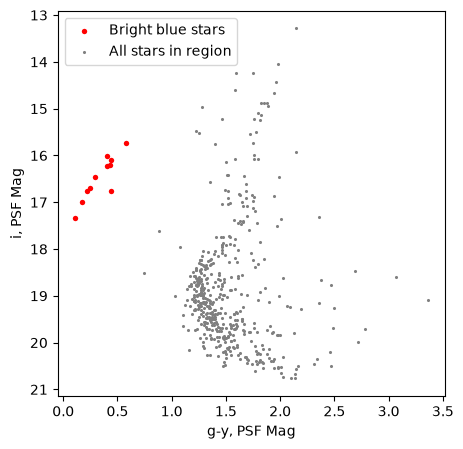

In [4]:
f, ax = plt.subplots()
f.set_size_inches((5,5))

# Stars meeting the color/magnitude cuts
ax.scatter(
    results_aq['gMeanPSFMag']-results_aq['yMeanPSFMag'],
    results_aq['iMeanPSFMag'], 
    s=15,lw=0, color='red',
    label='Bright blue stars',
)

# Plot the full set of stars for comparison
ax.scatter(
    results_aq_all['gMeanPSFMag']-results_aq_all['yMeanPSFMag'],
    results_aq_all['iMeanPSFMag'], 
    s=5,lw=0,zorder=-1, color='gray',
    label='All stars in region',
)

ax.legend()

ax.set_xlabel("g-y, PSF Mag")
ax.set_ylabel("i, PSF Mag")

ax.set_ylim(ax.get_ylim()[::-1])    # Invert for correct magnitude order

### Querying Roman Catalogs using MAST's TAP service using `pyvo`
It is also possible to access Roman catalogs via a TAP service at MAST, by submitting queries written in [ADQL](http://www.ivoa.net/documents/latest/ADQL.html). A benefit of constructing queries in the SQL-like language ADQL is that we can specify advanced query patterns, such as comparison constraints and derived constraints (i.e., as needed to apply the star/resolved and color criteria in this example), directly in the query. This makes it possible get the sample of interest in one query, avoiding a two step process where we load a larger sample into memory and then perform final cuts in our notebook.

For this second demonstration, we will apply the same selection criteria as above to select bright, blue stars near NGC 6535 from the PanSTARRS DR2 catalog.

First, we connect to the MAST PanSTARRS DR2 TAP service.


In [5]:
# Use `pyvo` to connect to the MAST PanSTARRS TAP service:
TAP_service = vo.dal.TAPService(
    "https://mast.stsci.edu/vo-tap/api/v0.1/mast_catalogs/"
)

Again, we will access the mean object catalog (`mean_object` here; see the [PanSTARRS DR2 catalogs documentation](https://outerspace.stsci.edu/spaces/PANSTARRS/pages/298812351/PS1+Source+extraction+and+catalogs)), which contains all the columns we will need.

Note that it is possible to use the TAP service to directly access catalog/table 
schemas, which describe the tables and columns. 
An example of this is provided here, commented out as we have pre-identified 
the relevent columns from the documentation

An overview description of methods, capabilities, and 
maximum result set sizes is available via:
```python
TAP_service.describe()
```

Additionally, the `pyvo` TAPService class objects contain 
metadata information about the full catalog schema, including tables and columns.
It's possible to iterate through the tables and print column names 
as in this code snippet (here, only printing columns for the `mean_object` table).
```python
TAP_tables = TAP_service.tables
for tablename in TAP_tables.keys():
    # This can be refined by table name to print columns only for subsets of tables.
    if (tablename.startswith("ps1_dr2.mean_object")):  # Include only PS1 tables 
        ####
        # The table descriptions only include an overview, so this also prints the column names
        TAP_tables[tablename].describe() 
        print("Columns={}".format(sorted([k.name for k in TAP_tables[tablename].columns])))
        print("----")
```

We now construct our query, including the color/magnitude constraints and 
star/extended object separation. As an overview, our query is constructed as follows.

We specify the table, `mean_object`, with the "FROM" statement.
The subset of columns to be returned (`objid`, `ramean`, `decmean`, `gmeanpsfmag`, `imeanpsfmag`, `ymeanpsfmag`, `imeankronmag`) are specified with the "SELECT" statement.
We then specify the query constraints in the "WHERE" statement, with multiple constraints linked using "AND". 
This includes:
* the cone search (as in the "CONTAINS(...)" clause; note that for ADQL, the radius must be expressed in degrees), 
* requiring the $g$, $i$, $y$ mean PSF magnitudes and $i$ mean Kron magnitude to be present (cutting objects that have any of these values missing),
* the PanSTARRS-specific cut to select stars (`imeanpsfmag - imeankronmag <= 0.05`), and 
* the $g-y$ color and $i$ magnitude cuts.


We then submit this query to the TAP service, and retrieve and display the table with the query results.

In [6]:
# Query MAST for matching observations in 
# the PanSTARRS DR2 mean catalog

# Note: ADQL comments are preceded by "--"
adql_query = f"""
SELECT objid, ramean, decmean, 
    gmeanpsfmag, imeanpsfmag, ymeanpsfmag, 
    imeankronmag
FROM mean_object
WHERE CONTAINS(
    POINT('ICRS', ramean, decmean),
    CIRCLE('ICRS',{c0.ra.deg}, {c0.dec.deg}, {(1.5*u.arcmin).to_value(u.deg)})          
)=1                                       -- 1.5 arcmin around NGC 6535
AND gmeanpsfmag > -999                    -- mag > -999; missing magnitudes are -999
AND imeanpsfmag > -999                    -- mag > -999; missing magnitudes are -999
AND ymeanpsfmag > -999                    -- mag > -999; missing magnitudes are -999
AND imeankronmag > -999                   -- mag > -999; missing magnitudes are -999
AND (imeanpsfmag - imeankronmag) <= 0.05  -- distinguish stars from extended objects
AND (gmeanpsfmag-ymeanpsfmag) < 0.8       -- color cut
AND imeanpsfmag < 18                      -- magnitude cut
"""

# Submit query to the MAST TAP service:
job = TAP_service.run_async(adql_query)

# Retrieve results:
results_tap = job.to_table()

# Final sample selection
results_tap

/home/runner/micromamba/envs/ci-env/lib/python3.11/site-packages/pyvo/dal/query.py:403: DALOverflowWarning: Results truncated due to server limits. Consider setting a maxrec value.
  warn("Results truncated due to server limits. Consider "


objid,ramean,decmean,gmeanpsfmag,imeanpsfmag,ymeanpsfmag,imeankronmag
,deg,deg,mag,mag,mag,mag
int64,float64,float64,float32,float32,float32,float32
107632709534144766,270.95338546879503,-0.3047455642018009,17.0765,16.7683,16.6352,16.7509
107642709657944948,270.9657688899816,-0.29625281205122417,16.4413,16.2274,16.0394,16.186
107662709570245695,270.9569986424153,-0.2789625156917366,16.862,16.693,16.6112,16.7813
107622709573665384,270.957335353332,-0.3125668951948708,17.4472,17.3332,17.3366,17.4682
107642709703759594,270.9703642717264,-0.2923859347624948,16.6545,16.4703,16.3595,16.4361
107632709733451952,270.97331765199516,-0.3070894397722286,16.9254,16.7628,16.7023,16.8846
107662709583301962,270.9583027798802,-0.28207893918943006,17.1175,16.99,16.9489,17.0684
107622709526829524,270.9526486988225,-0.30911800835201964,16.4645,16.1943,16.0325,16.2402


By leveraging the advanced usage patterns possible with AQDL, this single TAP query returns the same results as our two-step `astroquery` example where we first queried and then applied the final cuts.

(For this simple example, applying such cuts in memory are not prohibitive, but for cases where the selected sample may be large, performing all cuts server-side can be much more performant.)


We confirm that both methods yield the same set of objects by sorting the two result tables by object ID, and checking that all object IDs are the same.

In [7]:
# Sort both by objid
results_aq.sort('objID')
results_tap.sort('objid')
# Check the ID lists are the same:
print(np.all(results_aq['objID'] == results_tap['objid']))

True


*********


## Additional Resources
Additional information can be found at the following links:

### Other RRN notebooks
- [Data Discovery and Access:](../data_discovery_and_access/data_discovery_and_access.ipynb) The next step in this workflow, covering how to search for and access (particularly cloud streaming access) of file-based Roman products.

### MAST notebooks
- [MAST Table Access Protocol PanSTARRS 1 DR2 Demo](https://spacetelescope.github.io/mast_notebooks/notebooks/PanSTARRS/PS1_DR2_TAP/PS1_DR2_TAP.html), providing a more in-depth tutorial about constructing ADQL queries and using MAST TAP services.

### Other resources
- [RDox Level 4 Product Documentation](https://roman-docs.stsci.edu/data-handbook/wfi-data-levels-and-products#WFIDataLevelsandProducts-Level4-ExtractedDataLevel4), including catalog products.
- [`astroquery.mast.Catalogs` search documentation](https://astroquery.readthedocs.io/en/latest/mast/mast_catalog.html)
- [Documentation for `pyvo`](https://pyvo.readthedocs.io/en/latest/index.html), a package to retrieve astronomical data available from archives that support standard IVOA virtual observatory service protocols.
- [Documentation on ADQL](http://www.ivoa.net/documents/latest/ADQL.html), covering the specifications of this IVOA standard for querying astronomical data in tabular format, with geometric search support.
- [Documentation on TAP](http://www.ivoa.net/documents/TAP/), the IVOA standard for RESTful web service access to tabular data.
- [Full list of TAP services at MAST](https://mast.stsci.edu/vo-tap)


### Citations and acknowledgements
* [Citing `astropy`](https://www.astropy.org/acknowledging.html)
* [Acknowledging PanSTARRS](https://archive.stsci.edu/publishing/mission-acknowledgements#section-895d38a0-86b3-4143-b521-6cc3312701f9)
* [Acknowledging MAST](https://archive.stsci.edu/gsc/mast_data_use.html)

******

## About this Notebook
The information about TAP access is based on the TIKE MAST PanSTARRS DR2 TAP notebook by Rick White & Theresa Dower, with edits from T. Dutkiewicz. 

**Author:**  Sedona Price\
**Updated On:** 2026-04-08

<table width="100%" style="border:none; border-collapse:collapse;">

  <tr style="border:none;">
    <td style="border:none; width:180px; white-space:nowrap;">
       <a href="#top" style="text-decoration:none; color:#0066cc;"> Top of page</a>
    </td>
    <td style="border:none; text-align:center;">
        <img src="https://raw.githubusercontent.com/spacetelescope/roman_notebooks/refs/heads/main/roman_logo.png" alt="roman_logo" width="50px">
    </td>
    <td style="border:none; text-align:right;">
       <img src="https://raw.githubusercontent.com/spacetelescope/roman_notebooks/refs/heads/main/stsci_logo2.png" width="90">
    </td>
  </tr>
</table>